# Lysbro Platform Analytics

This notebook reads from the analytics database produced by `etl.py` and visualises key business metrics for the Lysbro video conferencing platform.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.facecolor': '#05070f',
    'axes.facecolor':   '#080b18',
    'axes.edgecolor':   '#1e293b',
    'axes.labelcolor':  '#94a3b8',
    'xtick.color':      '#475569',
    'ytick.color':      '#475569',
    'text.color':       '#e2e8f0',
    'grid.color':       '#1e293b',
    'grid.linestyle':   '--',
    'font.family':      'sans-serif',
})

BLUE   = '#3b82f6'
CYAN   = '#06b6d4'
PURPLE = '#a78bfa'
GREEN  = '#22c55e'
AMBER  = '#f59e0b'

db = sqlite3.connect('output/lysbro_analytics.db')
print('Connected to analytics database')

Connected to analytics database


## 1. Plan Distribution

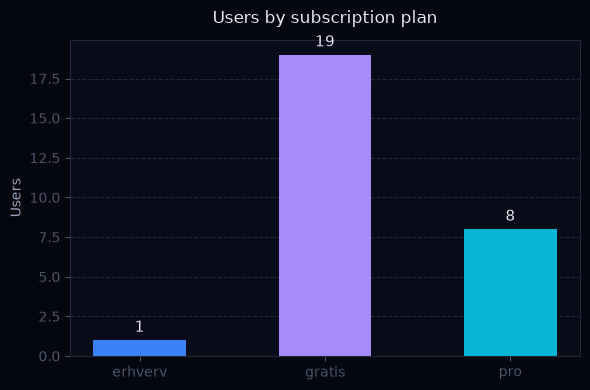

,plan,user_count
0,erhverv,1
1,gratis,19
2,pro,8


In [2]:
plans = pd.read_sql('SELECT * FROM plan_distribution', db)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(plans['plan'], plans['user_count'], color=[BLUE, PURPLE, CYAN], width=0.5)
for bar, val in zip(bars, plans['user_count']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(val), ha='center', va='bottom', color='#e2e8f0', fontsize=11)
ax.set_title('Users by subscription plan', color='#e2e8f0', pad=12)
ax.set_ylabel('Users')
ax.yaxis.grid(True)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('output/plan_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
plans

## 2. Monthly Signups

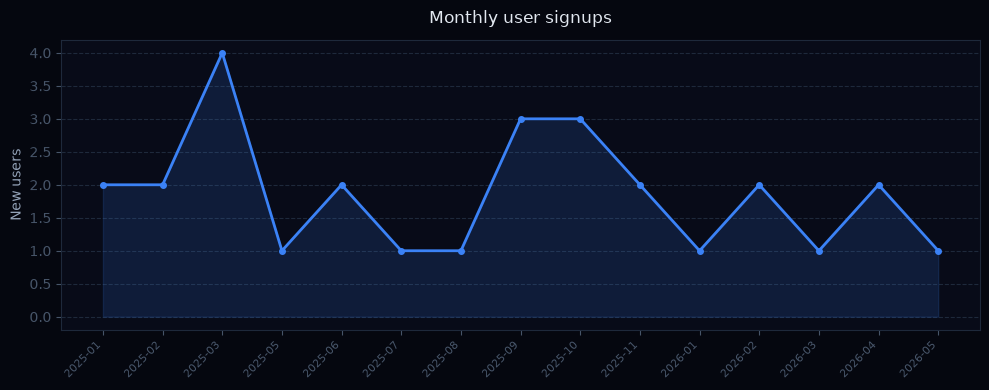

In [3]:
signups = pd.read_sql('SELECT * FROM monthly_signups', db)

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(range(len(signups)), signups['signups'], alpha=0.15, color=BLUE)
ax.plot(range(len(signups)), signups['signups'], color=BLUE, linewidth=2, marker='o', markersize=4)
ax.set_xticks(range(len(signups)))
ax.set_xticklabels(signups['month'], rotation=45, ha='right', fontsize=8)
ax.set_title('Monthly user signups', color='#e2e8f0', pad=12)
ax.set_ylabel('New users')
ax.yaxis.grid(True)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('output/monthly_signups.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Monthly Meetings

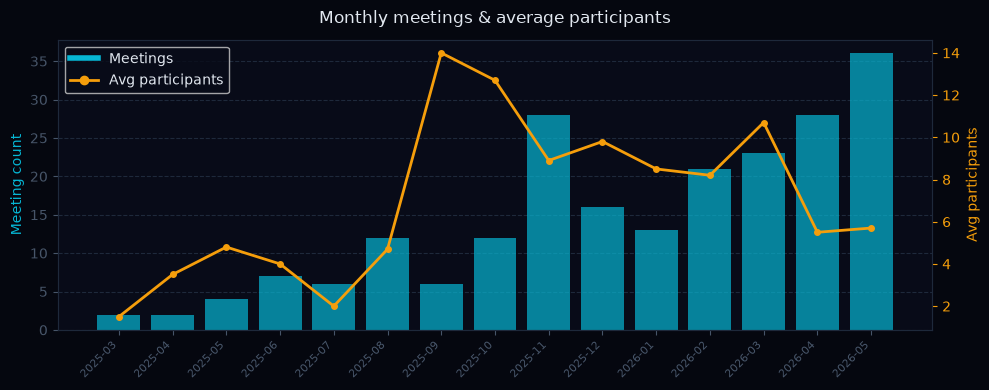

In [4]:
mm = pd.read_sql('SELECT * FROM monthly_meetings', db)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

ax1.bar(range(len(mm)), mm['meeting_count'], color=CYAN, alpha=0.7)
ax2.plot(range(len(mm)), mm['avg_participants'], color=AMBER, linewidth=2, marker='o', markersize=4)

ax1.set_xticks(range(len(mm)))
ax1.set_xticklabels(mm['month'], rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Meeting count', color=CYAN)
ax2.set_ylabel('Avg participants', color=AMBER)
ax2.tick_params(colors=AMBER)
ax1.set_title('Monthly meetings & average participants', color='#e2e8f0', pad=12)
ax1.yaxis.grid(True)
ax1.set_axisbelow(True)

legend_handles = [
    plt.Line2D([0], [0], color=CYAN, linewidth=4, label='Meetings'),
    plt.Line2D([0], [0], color=AMBER, linewidth=2, marker='o', label='Avg participants'),
]
ax1.legend(handles=legend_handles, loc='upper left')
plt.tight_layout()
plt.savefig('output/monthly_meetings.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. RSVP Acceptance Rate

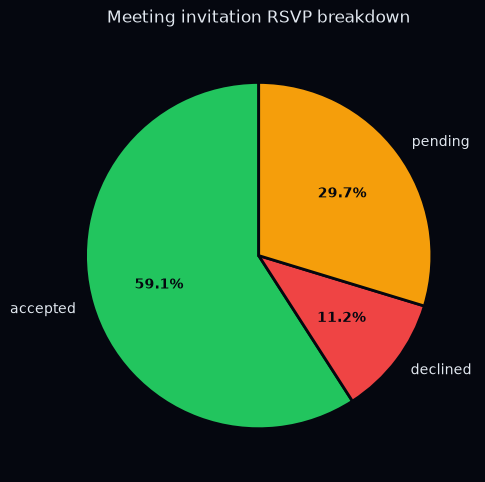

,rsvp,count,pct
0,accepted,977,59.1
1,declined,185,11.2
2,pending,491,29.7


In [5]:
rsvp = pd.read_sql('SELECT * FROM rsvp_summary', db)

color_map = {'accepted': GREEN, 'pending': AMBER, 'declined': '#ef4444'}
colors = [color_map.get(r, BLUE) for r in rsvp['rsvp']]

fig, ax = plt.subplots(figsize=(5, 5))
_, _, autotexts = ax.pie(
    rsvp['count'],
    labels=rsvp['rsvp'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': '#05070f', 'linewidth': 2},
)
for t in autotexts:
    t.set_color('#05070f')
    t.set_fontweight('bold')
ax.set_title('Meeting invitation RSVP breakdown', color='#e2e8f0', pad=12)
plt.tight_layout()
plt.savefig('output/rsvp_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
rsvp

## 5. Daily Message Volume (7-day rolling average)

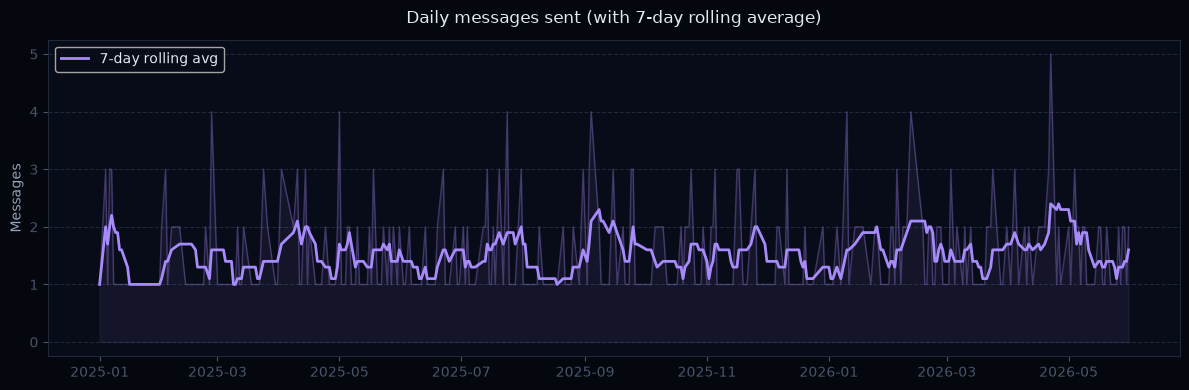

In [6]:
msgs = pd.read_sql('SELECT * FROM daily_messages', db)
msgs['date'] = pd.to_datetime(msgs['date'])

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(msgs['date'], msgs['messages_sent'], alpha=0.08, color=PURPLE)
ax.plot(msgs['date'], msgs['messages_sent'], color=PURPLE, alpha=0.3, linewidth=1)
ax.plot(msgs['date'], msgs['rolling_7d'], color=PURPLE, linewidth=2, label='7-day rolling avg')
ax.set_title('Daily messages sent (with 7-day rolling average)', color='#e2e8f0', pad=12)
ax.set_ylabel('Messages')
ax.yaxis.grid(True)
ax.set_axisbelow(True)
ax.legend()
plt.tight_layout()
plt.savefig('output/daily_messages.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Average Meetings per User by Plan

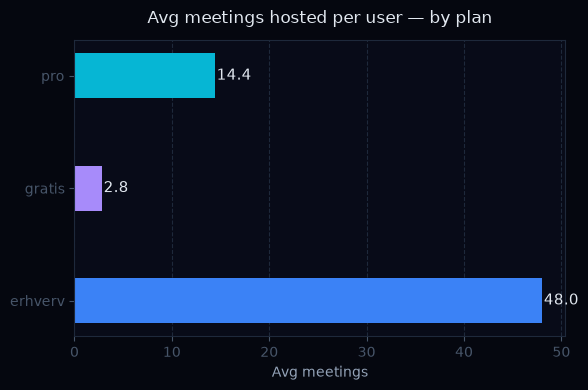

,plan,avg_meetings
0,erhverv,48.0
1,gratis,2.8
2,pro,14.4


In [7]:
mpu = pd.read_sql('SELECT * FROM meetings_per_user_by_plan', db)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(mpu['plan'], mpu['avg_meetings'], color=[BLUE, PURPLE, CYAN], height=0.4)
for bar, val in zip(bars, mpu['avg_meetings']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{val}', va='center', color='#e2e8f0', fontsize=11)
ax.set_title('Avg meetings hosted per user — by plan', color='#e2e8f0', pad=12)
ax.set_xlabel('Avg meetings')
ax.xaxis.grid(True)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('output/meetings_per_user.png', dpi=150, bbox_inches='tight')
plt.show()
mpu

In [8]:
db.close()
print('All charts saved to output/')

All charts saved to output/
